In [1]:
import pandas as pd

df = pd.read_csv("../data/cleaned_selected_columns.csv")
df.head()

,pl_orbper,pl_orbsmax,pl_orbeccen,P_RADIUS,P_MASS,P_DENSITY,P_FLUX,P_TEMP_EQUIL,st_teff,st_mass,S_RADIUS,S_LUMINOSITY,sy_dist,sy_pnum,P_HABITABLE,P_ESI
0,323.21000,1.178,0.238,12.2,4914.8985,2.706668,70.529631,730.24033,4874.0,2.09,13.76,95.060479,93.1846,1,0,0.087644
1,516.21997,1.530,0.080,12.3,4684.8142,2.517544,115.348340,833.83473,4213.0,2.78,29.79,269.153480,125.3210,1,0,0.081366
2,186.76000,0.775,0.000,13.1,1131.1513,0.503161,115.185180,834.54327,4888.0,1.78,11.55,69.183097,75.4392,1,0,0.077422
3,1765.03890,2.774,0.373,12.6,2559.4722,1.279495,0.098473,138.79412,5338.0,0.91,0.93,0.703072,17.9323,2,0,0.163020
4,798.50000,1.660,0.680,13.5,565.7374,0.229939,0.618806,202.19319,5750.0,1.08,1.13,1.250259,21.1397,1,0,0.368093


In [ ]:
import numpy as np

# --- Constants and conversion factors ---
G = 6.67430e-11            # m^3 kg^-1 s^-2
M_earth = 5.97219e24      # kg
R_earth = 6.371008e6      # m
M_sun = 1.98847e30        # kg
R_sun = 6.957e8           # m
AU_m = 1.495978707e11     # m
day_s = 86400.0
sigma_sb = 5.670374419e-8 # Stefan-Boltzmann constant in W/m^2/K^4
L_sun = 3.828e26          # W

# Working copy
df_work = df.copy()

In [3]:
# Helper to safely create derived columns and flags
def mark_derived(colname, mask, method):
    flag = colname + "_derived"
    df_work[flag] = df_work.get(flag, False)
    df_work.loc[mask, flag] = True
    df_work.loc[mask, colname + "_derived_method"] = method

In [ ]:
# ---------- 1) S_RADIUS from S_LUMINOSITY & st_teff ----------
# Catalog units: S_LUMINOSITY in L_sun, st_teff in K. Result will be in R_sun.
mask = df_work['S_RADIUS'].isna() & df_work['S_LUMINOSITY'].notna() & df_work['st_teff'].notna()
if mask.any():
    # L_star_W = S_LUMINOSITY * L_sun
    L_W = df_work.loc[mask, 'S_LUMINOSITY'].astype(float) * L_sun
    Teff = df_work.loc[mask, 'st_teff'].astype(float)
    # R_star_m = sqrt( L / (4*pi*sigma*T^4) )
    R_m = np.sqrt(L_W / (4 * np.pi * sigma_sb * (Teff**4)))
    # convert to R_sun
    R_Rsun = R_m / R_sun
    df_work.loc[mask, 'S_RADIUS'] = R_Rsun.values
    mark_derived('S_RADIUS', mask, 'from S_LUMINOSITY & st_teff via Stefan-Boltzmann')
print(f"S_RADIUS derived for {mask.sum()} rows from S_LUMINOSITY & st_teff")

S_RADIUS derived for 1 rows from S_LUMINOSITY & st_teff


In [5]:
# ---------- 2) S_LUMINOSITY from S_RADIUS & st_teff (if L missing but radius+teff present) ----------
mask = df_work['S_LUMINOSITY'].isna() & df_work['S_RADIUS'].notna() & df_work['st_teff'].notna()
if mask.any():
    R_m = df_work.loc[mask, 'S_RADIUS'].astype(float) * R_sun
    Teff = df_work.loc[mask, 'st_teff'].astype(float)
    L_W = 4 * np.pi * (R_m**2) * sigma_sb * (Teff**4)
    L_Lsun = L_W / L_sun
    df_work.loc[mask, 'S_LUMINOSITY'] = L_Lsun.values
    mark_derived('S_LUMINOSITY', mask, 'from S_RADIUS & st_teff via Stefan-Boltzmann')
print(f"S_LUMINOSITY derived for {mask.sum()} rows from S_RADIUS & st_teff")

S_LUMINOSITY derived for 0 rows from S_RADIUS & st_teff


In [6]:
# ---------- 3) pl_orbsmax from pl_orbper & st_mass (Kepler) ----------
# Inputs: pl_orbper in days, st_mass in solar masses. Output: AU
mask = df_work['pl_orbsmax'].isna() & df_work['pl_orbper'].notna() & df_work['st_mass'].notna()
if mask.any():
    P_days = df_work.loc[mask, 'pl_orbper'].astype(float)
    Mstar = df_work.loc[mask, 'st_mass'].astype(float) * M_sun
    P_s = P_days * day_s
    a_m = (G * Mstar * (P_s**2) / (4 * (np.pi**2)))**(1/3)
    a_AU = a_m / AU_m
    df_work.loc[mask, 'pl_orbsmax'] = a_AU.values
    mark_derived('pl_orbsmax', mask, 'from pl_orbper & st_mass via Kepler 3rd law')
print(f"pl_orbsmax derived for {mask.sum()} rows from pl_orbper & st_mass")

pl_orbsmax derived for 259 rows from pl_orbper & st_mass


In [7]:
# ---------- 4) P_FLUX from S_LUMINOSITY & pl_orbsmax ----------
# Convention: pl_flux (P_FLUX) in Earth flux units: F = L_star / a^2 (with L_star in L_sun and a in AU)
mask = df_work['P_FLUX'].isna() & df_work['S_LUMINOSITY'].notna() & df_work['pl_orbsmax'].notna()
if mask.any():
    Lstar_Lsun = df_work.loc[mask, 'S_LUMINOSITY'].astype(float)
    a_AU = df_work.loc[mask, 'pl_orbsmax'].astype(float)
    # avoid division by zero
    safe_a2 = a_AU**2
    df_work.loc[mask, 'P_FLUX'] = (Lstar_Lsun / safe_a2).values
    mark_derived('P_FLUX', mask, 'from S_LUMINOSITY & pl_orbsmax via inverse-square')
print(f"P_FLUX derived for {mask.sum()} rows from S_LUMINOSITY & pl_orbsmax")

P_FLUX derived for 0 rows from S_LUMINOSITY & pl_orbsmax


In [ ]:
# ---------- 5) P_TEMP_EQUIL from st_teff, S_RADIUS (or st_rad), pl_orbsmax ----------
# We assume Bond albedo A=0 and instantaneous reradiation; T_eq = T_star * sqrt(R_star / (2 a))
R_sun_AU = R_sun / AU_m  # ~0.00465 AU
mask = df_work['P_TEMP_EQUIL'].isna() & df_work['st_teff'].notna() & df_work['S_RADIUS'].notna() & df_work['pl_orbsmax'].notna()
# try S_RADIUS first (derived/stellar column)
if mask.any():
    Tstar = df_work.loc[mask, 'st_teff'].astype(float)
    Rstar_AU = df_work.loc[mask, 'S_RADIUS'].astype(float) * R_sun_AU
    a_AU = df_work.loc[mask, 'pl_orbsmax'].astype(float)
    Teq = Tstar * np.sqrt(Rstar_AU / (2.0 * a_AU))
    df_work.loc[mask, 'P_TEMP_EQUIL'] = Teq.values
    mark_derived('P_TEMP_EQUIL', mask, 'from st_teff & S_RADIUS & pl_orbsmax, albedo=0')
print(f"P_TEMP_EQUIL derived for {mask.sum()} rows from st_teff,S_RADIUS & pl_orbsmax")

P_TEMP_EQUIL derived for 0 rows from st_teff,S_RADIUS & pl_orbsmax


In [ ]:
mask2 = df_work['P_TEMP_EQUIL'].isna() & df_work['st_teff'].notna() & df_work['S_RADIUS'].notna() & df_work['pl_orbsmax'].notna()
if mask2.any():
    Tstar = df_work.loc[mask2, 'st_teff'].astype(float)
    Rstar_AU = df_work.loc[mask2, 'S_RADIUS'].astype(float) * R_sun_AU
    a_AU = df_work.loc[mask2, 'pl_orbsmax'].astype(float)
    Teq = Tstar * np.sqrt(Rstar_AU / (2.0 * a_AU))
    df_work.loc[mask2, 'P_TEMP_EQUIL'] = Teq.values
    mark_derived('P_TEMP_EQUIL', mask2, 'from st_teff & S_RADIUS & pl_orbsmax, albedo=0')
print(f"P_TEMP_EQUIL derived for {mask2.sum()} rows from st_teff,S_RADIUS & pl_orbsmax")

P_TEMP_EQUIL derived for 0 rows from st_teff,S_RADIUS & pl_orbsmax


In [ ]:
# ---------- 6) P_DENSITY from P_MASS & P_RADIUS ----------
# P_MASS in Earth masses, P_RADIUS in Earth radii; produce density in g/cm^3
mask = df_work['P_DENSITY'].isna() & df_work['P_MASS'].notna() & df_work['P_RADIUS'].notna()
if mask.any():
    Mp_kg = df_work.loc[mask, 'P_MASS'].astype(float) * M_earth
    Rp_m = df_work.loc[mask, 'P_RADIUS'].astype(float) * R_earth
    rho_kg_m3 = (3.0 * Mp_kg) / (4.0 * np.pi * (Rp_m**3))
    rho_g_cm3 = rho_kg_m3 / 1000.0
    df_work.loc[mask, 'P_DENSITY'] = rho_g_cm3.values
    mark_derived('P_DENSITY', mask, 'from P_MASS & P_RADIUS via bulk density formula')
print(f"P_DENSITY derived for {mask.sum()} rows from P_MASS & P_RADIUS")

P_DENSITY derived for 0 rows from P_MASS & P_RADIUS


In [ ]:
# ---------- Report summary ----------
derived_cols = [c for c in df_work.columns if c.endswith('_derived')]
print("\nDerived columns flags present (summary):")
for flag in derived_cols:
    orig = flag[:-8] 
    n = df_work[flag].sum()
    print(f"{orig}: derived for {int(n)} rows")


Derived columns flags present (summary):
S_RADIUS: derived for 1 rows
pl_orbsmax: derived for 259 rows


In [ ]:
print("\nRemaining missing in target derived columns:")
for col in ['P_DENSITY','P_FLUX','P_TEMP_EQUIL','S_RADIUS','S_LUMINOSITY','pl_orbsmax']:
    if col in df_work.columns:
        print(f"{col}: {df_work[col].isna().sum()} missing")



Remaining missing in target derived columns:
P_DENSITY: 7 missing
P_FLUX: 233 missing
P_TEMP_EQUIL: 224 missing
S_RADIUS: 230 missing
S_LUMINOSITY: 232 missing
pl_orbsmax: 4 missing


In [13]:
hab = df_work[df_work['P_HABITABLE'] == 1].copy()
print("Number of habitable planets:", hab.shape[0])

Number of habitable planets: 70


In [14]:
missing_counts = hab.isna().sum()
missing_counts[missing_counts > 0]

pl_orbeccen                  10
S_RADIUS_derived_method      70
pl_orbsmax_derived_method    68
dtype: int64

In [15]:
df_ = df_work[df.columns].copy()
df_.head()

,pl_orbper,pl_orbsmax,pl_orbeccen,P_RADIUS,P_MASS,P_DENSITY,P_FLUX,P_TEMP_EQUIL,st_teff,st_mass,S_RADIUS,S_LUMINOSITY,sy_dist,sy_pnum,P_HABITABLE,P_ESI
0,323.21000,1.178,0.238,12.2,4914.8985,2.706668,70.529631,730.24033,4874.0,2.09,13.76,95.060479,93.1846,1,0,0.087644
1,516.21997,1.530,0.080,12.3,4684.8142,2.517544,115.348340,833.83473,4213.0,2.78,29.79,269.153480,125.3210,1,0,0.081366
2,186.76000,0.775,0.000,13.1,1131.1513,0.503161,115.185180,834.54327,4888.0,1.78,11.55,69.183097,75.4392,1,0,0.077422
3,1765.03890,2.774,0.373,12.6,2559.4722,1.279495,0.098473,138.79412,5338.0,0.91,0.93,0.703072,17.9323,2,0,0.163020
4,798.50000,1.660,0.680,13.5,565.7374,0.229939,0.618806,202.19319,5750.0,1.08,1.13,1.250259,21.1397,1,0,0.368093


In [16]:
df_main = df_.drop(columns=["pl_orbeccen"])
ecc = df_["pl_orbeccen"]

In [17]:
rows_to_keep = df_main.dropna().index
df_reduced = df_.loc[rows_to_keep].copy()

In [18]:
df_reduced = df_reduced.dropna(subset=["pl_orbsmax"])

In [19]:
df_reduced.isna().sum()

pl_orbper         0
pl_orbsmax        0
pl_orbeccen     478
P_RADIUS          0
P_MASS            0
P_DENSITY         0
P_FLUX            0
P_TEMP_EQUIL      0
st_teff           0
st_mass           0
S_RADIUS          0
S_LUMINOSITY      0
sy_dist           0
sy_pnum           0
P_HABITABLE       0
P_ESI             0
dtype: int64

In [20]:
hab = df_reduced[df_reduced['P_HABITABLE'] == 1].copy()
print("Number of habitable planets:", hab.shape[0])

Number of habitable planets: 70


In [21]:
missing_counts = hab.isna().sum()
missing_counts[missing_counts > 0]

pl_orbeccen    10
dtype: int64

In [22]:
G = 6.67430e-11
M_sun = 1.98847e30
AU_m = 1.495978707e11
day_s = 86400

mask = df["pl_orbsmax"].notna() & df["st_mass"].notna() & df["pl_orbper"].notna()

P = df.loc[mask, "pl_orbper"].astype(float).values * day_s
M = df.loc[mask, "st_mass"].astype(float).values * M_sun
a_reported = df.loc[mask, "pl_orbsmax"].astype(float).values * AU_m  # convert AU → m

a_kepler = (G * M * P**2 / (4 * np.pi**2))**(1/3)

rel_error = np.abs(a_kepler - a_reported) / a_kepler

print("Kepler validation (Prior):")
print("Median relative error:", np.nanmedian(rel_error))
print("Max relative error:", np.nanmax(rel_error))
print("Rows with >5% error:", np.sum(rel_error > 0.05))

Kepler validation (Prior):
Median relative error: 0.006644755860653296
Max relative error: 1.4525074433194736
Rows with >5% error: 568


In [23]:
G = 6.67430e-11
M_sun = 1.98847e30
AU_m = 1.495978707e11
day_s = 86400

mask = df_reduced["pl_orbsmax"].notna() & df_reduced["st_mass"].notna() & df_reduced["pl_orbper"].notna()

P = df_reduced.loc[mask, "pl_orbper"].astype(float).values * day_s
M = df_reduced.loc[mask, "st_mass"].astype(float).values * M_sun
a_reported = df_reduced.loc[mask, "pl_orbsmax"].astype(float).values * AU_m  # convert AU → m

a_kepler = (G * M * P**2 / (4 * np.pi**2))**(1/3)

rel_error = np.abs(a_kepler - a_reported) / a_kepler

print("Kepler validation (Posterior):")
print("Median relative error:", np.nanmedian(rel_error))
print("Max relative error:", np.nanmax(rel_error))
print("Rows with >5% error:", np.sum(rel_error > 0.05))

Kepler validation (Posterior):
Median relative error: 0.005544322493184345
Max relative error: 1.4525074433194736
Rows with >5% error: 558


In [25]:
sigma = 5.670374419e-8
R_sun = 6.957e8
L_sun = 3.828e26

mask = df["S_LUMINOSITY"].notna() & df["S_RADIUS"].notna() & df["st_teff"].notna()

R = df.loc[mask, "S_RADIUS"].astype(float).values * R_sun
T = df.loc[mask, "st_teff"].astype(float).values
L_reported = df.loc[mask, "S_LUMINOSITY"].astype(float).values * L_sun

L_calc = 4 * np.pi * R**2 * sigma * T**4

rel_error_L = np.abs(L_calc - L_reported) / L_calc

print("Stefan–Boltzmann luminosity validation (Prior):")
print("Median relative error:", np.nanmedian(rel_error_L))
print("Max relative error:", np.nanmax(rel_error_L))
print("Rows with >10% error:", np.sum(rel_error_L > 0.1))

Stefan–Boltzmann luminosity validation (Prior):
Median relative error: 0.08775333258363997
Max relative error: 1019.4683787184243
Rows with >10% error: 2468


In [26]:
sigma = 5.670374419e-8
R_sun = 6.957e8
L_sun = 3.828e26

mask = df_reduced["S_LUMINOSITY"].notna() & df_reduced["S_RADIUS"].notna() & df_reduced["st_teff"].notna()

R = df_reduced.loc[mask, "S_RADIUS"].astype(float).values * R_sun
T = df_reduced.loc[mask, "st_teff"].astype(float).values
L_reported = df_reduced.loc[mask, "S_LUMINOSITY"].astype(float).values * L_sun

L_calc = 4 * np.pi * R**2 * sigma * T**4

rel_error_L = np.abs(L_calc - L_reported) / L_calc

print("Stefan–Boltzmann luminosity validation (Posterior):")
print("Median relative error:", np.nanmedian(rel_error_L))
print("Max relative error:", np.nanmax(rel_error_L))
print("Rows with >10% error:", np.sum(rel_error_L > 0.1))

Stefan–Boltzmann luminosity validation (Posterior):
Median relative error: 0.08775333258363997
Max relative error: 1019.4683787184243
Rows with >10% error: 2438


In [27]:
print("Negative radii:", (df_reduced["P_RADIUS"] < 0).sum())
print("Negative density:", (df_reduced["P_DENSITY"] < 0).sum())
print("Negative flux:", (df_reduced["P_FLUX"] < 0).sum())
print("Extremely high Teq (>5000 K):", (df_reduced["P_TEMP_EQUIL"] > 5000).sum())
print("Extremely low Teq (<10 K):", (df_reduced["P_TEMP_EQUIL"] < 10).sum())
print("Unreasonably high stellar luminosity (>10000 Lsun):", (df_reduced["S_LUMINOSITY"] > 1e4).sum())

Negative radii: 0
Negative density: 0
Negative flux: 0
Extremely high Teq (>5000 K): 2
Extremely low Teq (<10 K): 4
Unreasonably high stellar luminosity (>10000 Lsun): 0


In [28]:
df_reduced.columns

Index(['pl_orbper', 'pl_orbsmax', 'pl_orbeccen', 'P_RADIUS', 'P_MASS',
       'P_DENSITY', 'P_FLUX', 'P_TEMP_EQUIL', 'st_teff', 'st_mass', 'S_RADIUS',
       'S_LUMINOSITY', 'sy_dist', 'sy_pnum', 'P_HABITABLE', 'P_ESI'],
      dtype='object')

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from copy import deepcopy

# ---------------------------
# Config
# ---------------------------
RANDOM_STATE = 42
TEST_SIZE = 0.20
N_IMPUTATIONS = 7            # number of separate imputations to average
RF_N_ESTIMATORS = 300
GB_N_ESTIMATORS = 300

# Which columns to use as predictors.
PREDICTOR_COLS = ['pl_orbper', 'pl_orbsmax', 'P_RADIUS', 'P_MASS', 'P_DENSITY', 'P_FLUX', 'P_TEMP_EQUIL', 'st_teff', 'st_mass', 'S_RADIUS', 'S_LUMINOSITY', 'sy_dist', 'sy_pnum', 'P_HABITABLE', 'P_ESI']

# If some of these are not present in df, reduce the list:
PREDICTOR_COLS = [c for c in PREDICTOR_COLS if c in df_reduced.columns]

# The target column:
TARGET_COL = "pl_orbeccen"

In [30]:
# ---------------------------
# 0. Sanity: ensure predictors are numeric and have no missing values
# ---------------------------
X = df_reduced[PREDICTOR_COLS].copy()
y = df_reduced[TARGET_COL].copy()

if X.isna().any().any():
    raise ValueError("Predictor matrix X contains NaNs. Fill/derive/drop missing predictors before running this pipeline.")

In [31]:
# ---------------------------
# 1. Split known-data (rows where eccentricity is observed)
# ---------------------------
mask_known = y.notna()
X_known = X.loc[mask_known].reset_index(drop=True)
y_known = y.loc[mask_known].reset_index(drop=True)

# Rows to be imputed later:
mask_missing = y.isna()
X_missing = X.loc[mask_missing].reset_index()  # keep original index for assignment

# Train/test split on known values ONLY
X_train, X_test, y_train, y_test = train_test_split(
    X_known, y_known, test_size=TEST_SIZE, random_state=RANDOM_STATE, shuffle=True
)

print("Known rows:", len(X_known))
print("To-impute rows:", len(X_missing))
print("Train / Test sizes:", X_train.shape[0], X_test.shape[0])

Known rows: 4803
To-impute rows: 478
Train / Test sizes: 3842 961


In [32]:
# ---------------------------
# 2. Preprocessing: (optional) scaling
# We will scale numeric predictors for GB; RF does not need scaling but it's harmless.
# ---------------------------
scaler = StandardScaler()
scaler.fit(X_train)               # fit only on training set
X_train_s = pd.DataFrame(scaler.transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_s  = pd.DataFrame(scaler.transform(X_test),  columns=X_test.columns,  index=X_test.index)
X_missing_s = pd.DataFrame(scaler.transform(X_missing[PREDICTOR_COLS]), columns=PREDICTOR_COLS, index=X_missing.index)

In [ ]:
# ---------------------------
# 3. Model training & comparison (single-fit evaluation)
# ---------------------------
# Random Forest
rf = RandomForestRegressor(n_estimators=RF_N_ESTIMATORS, random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

# Gradient Boosting (sklearn's implementation)
gb = GradientBoostingRegressor(n_estimators=GB_N_ESTIMATORS, random_state=RANDOM_STATE)
gb.fit(X_train_s, y_train)  # use scaled inputs
y_pred_gb = gb.predict(X_test_s)
mae_gb = mean_absolute_error(y_test, y_pred_gb)
r2_gb = r2_score(y_test, y_pred_gb)

print("Model performance (on held-out test set):")
print(f"RandomForest   MAE: {mae_rf:.4f}, R2: {r2_rf:.4f}")
print(f"GradBoosting   MAE: {mae_gb:.4f}, R2: {r2_gb:.4f}")

# Choose the best model by MAE
if mae_gb < mae_rf:
    best_model_name = "GradientBoosting"
    base_model = gb
    use_scaler = True
else:
    best_model_name = "RandomForest"
    base_model = rf
    use_scaler = False

print(f"Selected best model: {best_model_name}")

Model performance (on held-out test set):
RandomForest   MAE: 0.0591, R2: 0.4980
GradBoosting   MAE: 0.0576, R2: 0.5639
Selected best model: GradientBoosting


In [34]:
# ---------------------------
# 4. Multiple imputations (bootstrap / different seeds)
# Method: re-fit the chosen estimator on bootstrap samples (to get variability)
# We'll vary random_state and use the same hyperparams on scaled data
# ---------------------------
imputed_arrays = []    # list of arrays (values) for missing rows (aligned to X_missing index)
models_for_ensem = []

for m in range(N_IMPUTATIONS):
    seed = RANDOM_STATE + m + 1
    if best_model_name == "RandomForest":
        model = RandomForestRegressor(n_estimators=RF_N_ESTIMATORS, random_state=seed, n_jobs=-1)
        # bootstrap sample of training set:
        boot_idx = np.random.choice(np.arange(X_train.shape[0]), size=X_train.shape[0], replace=True)
        Xb = X_train.iloc[boot_idx]
        yb = y_train.iloc[boot_idx]
        model.fit(Xb, yb)
        Xmiss_in = X_missing[PREDICTOR_COLS]  # unscaled
        preds = model.predict(Xmiss_in)
    else:  # GradientBoosting
        model = GradientBoostingRegressor(n_estimators=GB_N_ESTIMATORS, random_state=seed)
        boot_idx = np.random.choice(np.arange(X_train_s.shape[0]), size=X_train_s.shape[0], replace=True)
        Xb = X_train_s.iloc[boot_idx]
        yb = y_train.iloc[boot_idx]
        model.fit(Xb, yb)
        Xmiss_in = X_missing_s  # scaled
        preds = model.predict(Xmiss_in)
    imputed_arrays.append(preds)
    models_for_ensem.append(model)

# Stack imputations: shape (n_imputations, n_missing_rows)
imputed_matrix = np.vstack(imputed_arrays)

In [35]:
# ---------------------------
# 5. Aggregate imputations: average + compute std for uncertainty
# ---------------------------
imputed_mean = np.nanmean(imputed_matrix, axis=0)
imputed_std  = np.nanstd(imputed_matrix, axis=0)

# Put back into a copy of df; use original indices (X_missing index holds original df indices)
df_imputed = df_reduced.copy()
df_imputed.loc[X_missing['index'].values, TARGET_COL] = imputed_mean

# Save ensemble predictions alongside
ensemble_col_mean = TARGET_COL + "_imp_mean"
ensemble_col_std  = TARGET_COL + "_imp_std"
df_imputed.loc[X_missing['index'].values, ensemble_col_mean] = imputed_mean
df_imputed.loc[X_missing['index'].values, ensemble_col_std] = imputed_std

print("Multiple imputations done. Averaged predictions placed into DataFrame.")

Multiple imputations done. Averaged predictions placed into DataFrame.


In [36]:
# ---------------------------
# 6. Monotonicity / sanity checks & neighborhood outlier detection
#  - enforce physical bounds: 0 <= e < 1
#  - for each imputed row: find k nearest neighbors among known-data (in predictor space)
#    and ensure imputed value is within [min_neighbor - tol, max_neighbor + tol]
#    otherwise flag and optionally clip to neighbor range.
# ---------------------------
# 6.1 Enforce hard bounds
df_imputed[TARGET_COL] = df_imputed[TARGET_COL].clip(lower=0.0, upper=0.9999)

# 6.2 Neighborhood-check
K = 10
tol_std = 3.0   # allowed number of stds beyond neighbor mean before flagging

# Build neighbors on FULL known set (use scaler choice consistent with model)
if best_model_name == "GradientBoosting":
    nbr_space = scaler.transform(X_known)  # scaled
else:
    nbr_space = X_known.values  # raw

nbrs = NearestNeighbors(n_neighbors=K, algorithm='auto').fit(nbr_space)
# For each missing row, compute neighbor ecc stats
flags = []
clip_counts = 0
for i, row in X_missing.iterrows():
    # prepare the query point in correct space
    if best_model_name == "GradientBoosting":
        q = scaler.transform(row[PREDICTOR_COLS].to_frame().T)[0].reshape(1, -1)
    else:
        q = row[PREDICTOR_COLS].values.reshape(1, -1)
    dists, idxs = nbrs.kneighbors(q)
    neigh_idx = idxs[0]
    neigh_e = y_known.iloc[neigh_idx].values
    neigh_mean = np.mean(neigh_e)
    neigh_std  = np.std(neigh_e)
    imputed_val = df_imputed.loc[row["index"], TARGET_COL]
    # Flag if imputed value is > neigh_mean + tol_std * neigh_std or < neigh_mean - tol_std * neigh_std
    if neigh_std == 0:
        # if neighbors all same, allow small epsilon deviation; otherwise mark if different
        if not (neigh_mean - 1e-6 <= imputed_val <= neigh_mean + 1e-6):
            flags.append((row["index"], imputed_val, neigh_mean, neigh_std, "neighbor-const-flag"))
            # clip to neighbor range
            df_imputed.loc[row["index"], TARGET_COL] = np.clip(imputed_val, neigh_mean - 1e-6, neigh_mean + 1e-6)
            clip_counts += 1
    else:
        upper = neigh_mean + tol_std * neigh_std
        lower = neigh_mean - tol_std * neigh_std
        if imputed_val > upper or imputed_val < lower:
            flags.append((row["index"], imputed_val, neigh_mean, neigh_std, "neighbor-outlier-flag"))
            # Option: clip to neighbor bounds extended by tol_std
            clipped = np.clip(imputed_val, lower, upper)
            df_imputed.loc[row["index"], TARGET_COL] = clipped
            clip_counts += 1

print(f"Neighborhood sanity check completed. Flags raised: {len(flags)}. Values clipped: {clip_counts}")

# Save flags to DataFrame for later inspection
flag_df = pd.DataFrame(flags, columns=["orig_index","imputed_value","neighbor_mean","neighbor_std","reason"])
if not flag_df.empty:
    print("Example flagged imputations (first 10):")
    print(flag_df.head(10))

Neighborhood sanity check completed. Flags raised: 72. Values clipped: 72
Example flagged imputations (first 10):
   orig_index  imputed_value  neighbor_mean  neighbor_std  \
0       132.0       0.013293          0.000      0.000000   
1       135.0       0.014130          0.000      0.000000   
2       138.0       0.010328          0.000      0.000000   
3       139.0       0.045764          0.000      0.000000   
4       144.0       0.009379          0.000      0.000000   
5       151.0       0.009926          0.000      0.000000   
6       152.0       0.007416          0.000      0.000000   
7       155.0       0.057757          0.008      0.016056   
8       158.0       0.008457          0.000      0.000000   
9      1352.0       0.031233          0.000      0.000000   

                  reason  
0    neighbor-const-flag  
1    neighbor-const-flag  
2    neighbor-const-flag  
3    neighbor-const-flag  
4    neighbor-const-flag  
5    neighbor-const-flag  
6    neighbor-const-flag 

In [37]:
# ---------------------------
# 7. Evaluate imputer on test set (final best-model evaluation for reporting)
# ---------------------------
# Refit best model on full known set (optional) then evaluate on test set predictions we computed earlier:
# We'll compute final test MAE using the base_model predictions earlier (y_pred_rf or y_pred_gb)
if best_model_name == "RandomForest":
    final_mae = mae_rf
    final_r2  = r2_rf
else:
    final_mae = mae_gb
    final_r2  = r2_gb

print("Final selected imputer performance on held-out test set:")
print(f"Model: {best_model_name}; MAE = {final_mae:.4f}; R2 = {final_r2:.4f}")

Final selected imputer performance on held-out test set:
Model: GradientBoosting; MAE = 0.0576; R2 = 0.5639


In [38]:
# ---------------------------
# 8. Output / save results
# ---------------------------
# df_imputed now contains:
# - TARGET_COL: imputed values where original was missing (and original values where present)
# - TARGET_COL_imp_mean, TARGET_COL_imp_std columns with ensemble stats for imputed rows
# - optionally: save the flagged rows for inspection
df_imputed.to_csv("../data/eccentricity_imputed_dataset.csv", index=False)
if not flag_df.empty:
    flag_df.to_csv("../data/eccentricity_imputation_flags.csv", index=False)

print("Imputed dataset and flags saved to disk.")

Imputed dataset and flags saved to disk.


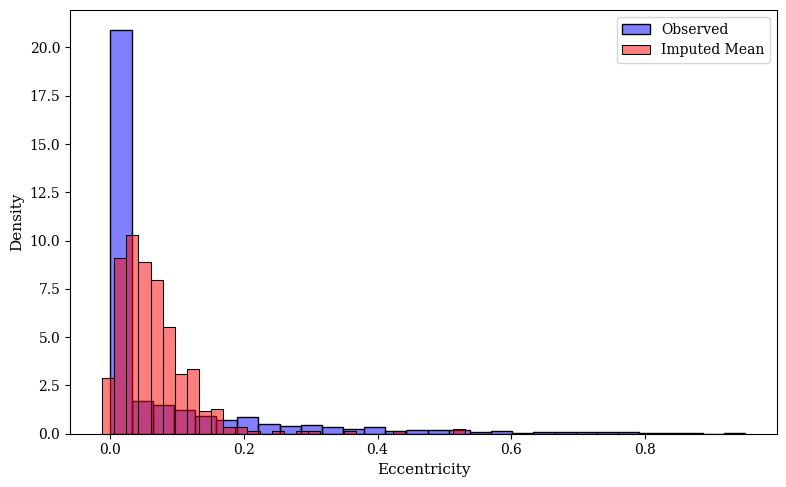

In [48]:
# -------------------------------------------------------------
# DIAGNOSTIC PLOTS FOR ECCENTRICITY IMPUTATION QUALITY
# -------------------------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams.update({
    # Font family (journal-safe)
    "font.family": "serif",
    "font.size": 11,

    # Axis labels and ticks
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,

    # Legend
    "legend.fontsize": 10,

    # Line widths
    "axes.linewidth": 0.8,
    "lines.linewidth": 1.2,

    # PDF font embedding (CRITICAL)
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})

# -----------------------------------------
# 1. Observed vs. Imputed Histogram
# -----------------------------------------
plt.figure(figsize=(8, 5))

obs_vals = df_imputed.loc[df_reduced[TARGET_COL].notna(), TARGET_COL]   # observed
imp_vals = df_imputed.loc[df_reduced[TARGET_COL].isna(), ensemble_col_mean]  # imputed mean

sns.histplot(obs_vals, bins=30, stat='density', color='blue', alpha=0.5, label='Observed')
sns.histplot(imp_vals, bins=30, stat='density', color='red', alpha=0.5, label='Imputed Mean')

plt.xlabel("Eccentricity")
plt.ylabel("Density")
# plt.title("Observed vs. Imputed Eccentricity Distributions")
plt.legend()
plt.tight_layout()

plt.savefig("imputation_a.pdf")

plt.show();

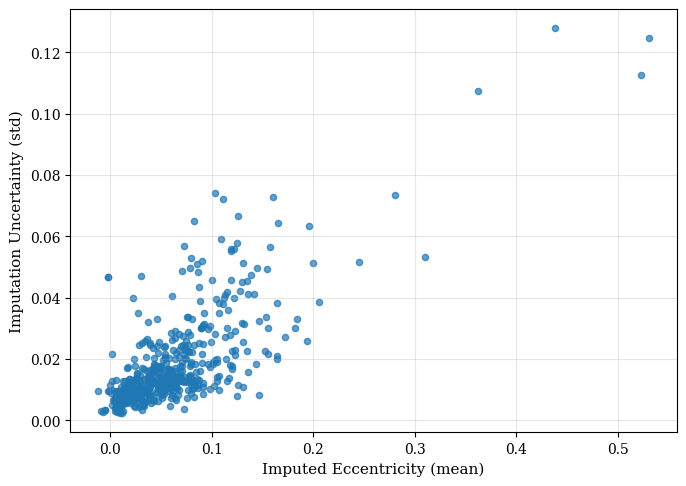

In [49]:
# ---------------------------------------------------------
# 2. Imputation Uncertainty Plot (mean vs std of imputations)
# ---------------------------------------------------------
plt.figure(figsize=(7,5))

imp_std = df_imputed.loc[df_reduced[TARGET_COL].isna(), ensemble_col_std]
plt.scatter(imp_vals, imp_std, s=20, alpha=0.7)

plt.xlabel("Imputed Eccentricity (mean)")
plt.ylabel("Imputation Uncertainty (std)")
# plt.title("Imputation Uncertainty Across Missing Rows")
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig("imputation_b.pdf")
plt.show();

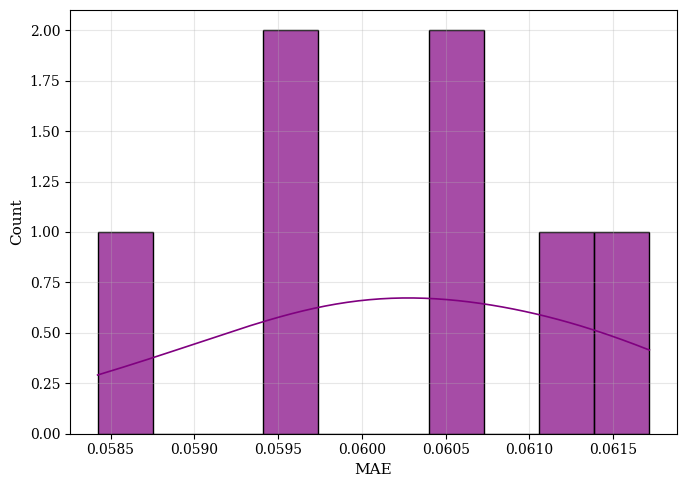

MAE stats across imputers:
Mean  MAE: 0.06021432498998253
STD   MAE: 0.0010375541950731408
Min   MAE: 0.05842271578183556
Max   MAE: 0.06171596570630035


In [ ]:
# ---------------------------------------------------------
# 3. MAE Distribution Across Multiple Imputations (bootstrap)
# ---------------------------------------------------------

mae_list = []
for m, model in enumerate(models_for_ensem):
    # predict on test set
    if best_model_name == "GradientBoosting":
        y_pred_boot = model.predict(X_test_s)
    else:
        y_pred_boot = model.predict(X_test)

    mae_list.append(mean_absolute_error(y_test, y_pred_boot))

plt.figure(figsize=(7,5))
sns.histplot(mae_list, bins=10, kde=True, color='purple', alpha=0.7)
plt.xlabel("MAE")
# plt.title("Distribution of Test MAE Across Multiple Imputations")
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig("imputation_c.pdf")
plt.show()

print("MAE stats across imputers:")
print("Mean  MAE:", np.mean(mae_list))
print("STD   MAE:", np.std(mae_list))
print("Min   MAE:", np.min(mae_list))
print("Max   MAE:", np.max(mae_list))

In [42]:
TARGET = "pl_orbeccen"

# Start with the imputed dataframe
df_minimal = df_imputed.copy()

# Remove uncertainty columns if present
cols_to_drop = [
    TARGET + "_imp_mean",
    TARGET + "_imp_std"
]

for c in cols_to_drop:
    if c in df_minimal.columns:
        df_minimal = df_minimal.drop(columns=[c])

# Remove helper columns if present
helper_cols = ["index", TARGET + "_derived", TARGET + "_derived_method"]
for c in helper_cols:
    if c in df_minimal.columns:
        df_minimal = df_minimal.drop(columns=[c])

# Sort rows by original order
df_minimal = df_minimal.sort_index()

# Final integrity check: no missing values should remain
print("Missing values per column:")
print(df_minimal.isna().sum())

# Save the compact dataset
output_path = "../data/final_data.csv"
df_minimal.to_csv(output_path, index=False)

print(f"\nMinimal ML-ready dataset saved to: {output_path}")

Missing values per column:
pl_orbper       0
pl_orbsmax      0
pl_orbeccen     0
P_RADIUS        0
P_MASS          0
P_DENSITY       0
P_FLUX          0
P_TEMP_EQUIL    0
st_teff         0
st_mass         0
S_RADIUS        0
S_LUMINOSITY    0
sy_dist         0
sy_pnum         0
P_HABITABLE     0
P_ESI           0
dtype: int64

Minimal ML-ready dataset saved to: ../data/final_data.csv


In [43]:
df_minimal.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5281 entries, 0 to 5575
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   pl_orbper     5281 non-null   float64
 1   pl_orbsmax    5281 non-null   float64
 2   pl_orbeccen   5281 non-null   float64
 3   P_RADIUS      5281 non-null   float64
 4   P_MASS        5281 non-null   float64
 5   P_DENSITY     5281 non-null   float64
 6   P_FLUX        5281 non-null   float64
 7   P_TEMP_EQUIL  5281 non-null   float64
 8   st_teff       5281 non-null   float64
 9   st_mass       5281 non-null   float64
 10  S_RADIUS      5281 non-null   float64
 11  S_LUMINOSITY  5281 non-null   float64
 12  sy_dist       5281 non-null   float64
 13  sy_pnum       5281 non-null   int64  
 14  P_HABITABLE   5281 non-null   int64  
 15  P_ESI         5281 non-null   float64
dtypes: float64(14), int64(2)
memory usage: 830.4 KB


In [44]:
df_minimal[df_minimal['P_HABITABLE'] == 1].shape

(70, 16)